In [21]:
import subprocess
import sys

# Instalar PuLP se não estiver presente
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pulp"])
print("✓ PuLP instalado com sucesso!")


✓ PuLP instalado com sucesso!


# Modelo Prescritivo

## Funções dos Modelos

- **Modelo preditivo** → estima probabilidades  
- **Modelo prescritivo** → toma decisão ótima com base nessas probabilidades  

## Perguntas que cada UM responde

- **Preditivo**: “Qual a chance?”  
- **Prescritivo**: “O que eu devo fazer?”  

## Ferramenta utilizada

Vamos utilizar  **Otimização Linear Inteira Binária** - 
- Usa equações lineares;
- Busca maximizar ou minimizar algo;
- Só permite decisões 0 ou 1.


## Estrutura do Notebook

1. **Carregamento de Dados**: Importação dos vídeos do YouTube
2. **Cálculo de Probabilidades**: Estimativa de retenção com base em engagement
3. **Otimização**: Seleção da melhor combinação de 3 vídeos
4. **Análise Visual**: Comparação dos vídeos candidatos
5. **Modelo Avançado**: Consideração de diversidade de categorias


# Carregamento e Preparação dos Dados

## Fonte de Dados

- **Arquivo**: `/database/YT_API/curtidas.csv`
- **Conteúdo**: Dados de vídeos do YouTube com métricas de engagement

## Cálculo da Probabilidade de Retenção

A probabilidade de retenção é calculada como uma **combinação ponderada** de:

1. **Engagement Rate** (50%) → `like_count / view_count`
2. **Likes Normalizados** (30%) → escala 0-1
3. **Views Normalizadas** (20%) → escala 0-1

**Fórmula**:
```
prob_retenção = 0.5 × engagement_rate + 0.3 × like_norm + 0.2 × view_norm
```

Esta métrica reflete a capacidade de cada vídeo reter a atenção dos usuários.


## Seleção dos Candidatos

Esta seção:
1. Carrega todos os vídeos do CSV
2. Calcula a probabilidade de retenção para cada um
3. Seleciona o **top-5** para a otimização

Os 5 vídeos com maior potencial de retenção serão os candidatos para a combinação final.


In [3]:
## IMPORTAÇÕES

import sys
import os
import pulp
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Carregar dados dos vídeos
caminho_csv = os.path.abspath("../database/YT_API/curtidas.csv")
df_videos = pd.read_csv(caminho_csv)

## CARREGANDO RESULTADOS DO MODELO PREDITIVO
sys.path.append(os.path.abspath("../predictive_model"))

from predictive_model import (
    recomendar_top_n,
    modelo,
    le_titulo,
    le_proximo,
    le_periodo
)

ModuleNotFoundError: No module named 'predictive_model'

In [ ]:
## CALCULAR PROBABILIDADES DE RETENÇÃO

# Usar uma combinação de engagement metrics como proxy de probabilidade de retenção
# Retenção = (like_count / view_count) + (view_count normalizado) + (engagement ratio)

# Normalizar view_count e like_count
scaler = MinMaxScaler(feature_range=(0, 1))
df_videos['view_norm'] = scaler.fit_transform(df_videos[['view_count']])
df_videos['like_norm'] = scaler.fit_transform(df_videos[['like_count']])

# Calcular taxa de engagement (like/view)
df_videos['engagement_rate'] = df_videos['like_count'] / (df_videos['view_count'] + 1)

# Probabilidade de retenção = média ponderada
# 50% do engagement rate + 30% da normalização de likes + 20% da normalização de views
df_videos['prob_retenção'] = (
    0.5 * df_videos['engagement_rate'] + 
    0.3 * df_videos['like_norm'] + 
    0.2 * df_videos['view_norm']
)

# Selecionar top-5 vídeos por probabilidade de retenção
top_videos = df_videos.nlargest(5, 'prob_retenção')[['video_id', 'titulo', 'prob_retenção', 'like_count', 'view_count']]

print("\n" + "="*80)
print("TOP 5 VÍDEOS POR PROBABILIDADE DE RETENÇÃO") 
print("="*80)
print(top_videos.to_string(index=False))
print()

# Criar dicionário de probabilidades para otimização
videos_ids = top_videos['video_id'].tolist()
probabilidades = dict(zip(videos_ids, top_videos['prob_retenção'].values))
titulos_map = dict(zip(top_videos['video_id'], top_videos['titulo']))

print(f"\nVídeos para combinação: {videos_ids}")
print(f"Probabilidades: {probabilidades}")



TOP 5 VÍDEOS POR PROBABILIDADE DE RETENÇÃO
   video_id                                                                                          titulo  prob_retenção  like_count  view_count
kxgEBpTEqtE Yes！successfully completed the water ninja#stunt #extremesports #parkour #funny #pov #waterpark       0.511750     9000251   382980999
VQRLujxTm3c                                                                   Grand Theft Auto VI Trailer 2       0.312896     6378334   151822879
BOmTTKTQceM                                                   CRAZIEST IMPOSSIBLE SHOT YET 🤯🏒 @AlwaysHockey       0.309116     6253416   153871003
8VKD-IlvibI                                                                                          Unholy       0.249590     2587057   304684287
tKtpyYGhI5M                                                      Can Starbucks Spell Footballers’ Names? ☕️       0.241908     4568742   140475340


Vídeos para combinação: ['kxgEBpTEqtE', 'VQRLujxTm3c', 'BOmTTKTQceM', '8

## Resumo dos Candidatos

Exibição das estatísticas básicas do dataset e dos 5 vídeos selecionados.


In [26]:
# Informações sobre os dados carregados
print(f"Total de vídeos carregados: {len(df_videos)}")
print(f"\nPrimeiros 5 vídeos do dataset:")
print(df_videos[['video_id', 'titulo', 'view_count', 'like_count']].head().to_string(index=False))
print(f"\nCategorias únicas: {df_videos['categoria_id'].nunique()}")
print(f"Canais únicos: {df_videos['canal_id'].nunique()}")


Total de vídeos carregados: 245

Primeiros 5 vídeos do dataset:
   video_id                                                                                            titulo  view_count  like_count
wXnBvfuSJwU                                                                       CONHEÇA UM CRUZEIRO DA MSC!          61           9
2zajmVK9DqU                           JOGO COMPLETO: NOVORIZONTINO X CORINTHIANS | PAULISTÃO 2026 | SEMIFINAL    11758666      416071
I5wQa_XFiNY bem-vindo ao Corinthians Jesse lingard #futebol #corinthians #futebolbrasileiro #loucosporfutebol        1357          93
AE3q5yvGdAI                                        Esse foi um jogão! #corinthians #futebolbrasileiro #grêmio      178756        7762
TYitKN4AKSw                                                      Meant to do that all along...😏 #rocketleague     3628088      145586

Categorias únicas: 13
Canais únicos: 142


## Problema de Otimização Linear Inteira

**Objetivo**: Maximizar a retenção total

**Variáveis de Decisão**: Variáveis binárias (0 ou 1) para cada vídeo

**Restrição Principal**: Selecionar exatamente **3 vídeos**

**Formulação**:
```
Maximizar: Σ (prob_retenção[v] × x[v])
Sujeito a: Σ x[v] = 3
           x[v] ∈ {0, 1}
```

O solver PuLP encontra a combinação que **maximiza a retenção total** respeitando a restrição.


In [ ]:
# ===== MODELO PRESCRITIVO PARA 3 VÍDEOS =====

# Reconstruir o problema para 3 vídeos
prob_3videos = pulp.LpProblem("Recomendacao_3Videos", pulp.LpMaximize)

# Variáveis binárias para cada vídeo
x_3 = pulp.LpVariable.dicts("video_3", videos_ids, cat='Binary')

# Função objetivo: maximizar a soma das probabilidades de retenção dos 3 vídeos
prob_3videos += pulp.lpSum(
    probabilidades[v] * x_3[v] 
    for v in videos_ids
), "Retenção_Total"

# Restrição: selecionar EXATAMENTE 3 vídeos
prob_3videos += pulp.lpSum([x_3[v] for v in videos_ids]) == 3, "Selecionar_3_Videos"

# Resolver o problema
prob_3videos.solve()

# Exibir resultados
print("\n" + "="*80)
print("SOLUÇÃO OTIMIZADA - COMBINAÇÃO DE 3 VÍDEOS PARA MÁXIMA RETENÇÃO")
print("="*80)

videos_selecionados = []
retenção_total = 0

for v in videos_ids:
    if x_3[v].value() == 1:
        videos_selecionados.append(v)
        retenção_total += probabilidades[v]
        titulo = titulos_map.get(v, "N/A")[:60]  # Truncar para 60 caracteres
        print(f"\n✓ {titulo}")
        print(f"  Video ID: {v}")
        print(f"  Probabilidade de retenção: {probabilidades[v]:.4f} ({probabilidades[v]:.2%})")

print("\n" + "-"*80)
print(f"RETENÇÃO TOTAL DA COMBINAÇÃO: {retenção_total:.4f} ({retenção_total:.2%})")
print(f"QUANTIDADE DE VÍDEOS: {len(videos_selecionados)}")
print(f"MÉDIA DE RETENÇÃO POR VÍDEO: {retenção_total/len(videos_selecionados):.4f}")
print("-"*80)



SOLUÇÃO OTIMIZADA - COMBINAÇÃO DE 3 VÍDEOS PARA MÁXIMA RETENÇÃO

✓ Yes！successfully completed the water ninja#stunt #extremespo
  Video ID: kxgEBpTEqtE
  Probabilidade de retenção: 0.5118 (51.18%)

✓ Grand Theft Auto VI Trailer 2
  Video ID: VQRLujxTm3c
  Probabilidade de retenção: 0.3129 (31.29%)

✓ CRAZIEST IMPOSSIBLE SHOT YET 🤯🏒 @AlwaysHockey
  Video ID: BOmTTKTQceM
  Probabilidade de retenção: 0.3091 (30.91%)

--------------------------------------------------------------------------------
RETENÇÃO TOTAL DA COMBINAÇÃO: 1.1338 (113.38%)
QUANTIDADE DE VÍDEOS: 3
MÉDIA DE RETENÇÃO POR VÍDEO: 0.3779
--------------------------------------------------------------------------------



COMPARAÇÃO DE TODOS OS VÍDEOS CANDIDATOS:
   Video_ID                                   Título  Probabilidade  Selecionado
kxgEBpTEqtE Yes！successfully completed the water nin       0.511750         True
VQRLujxTm3c            Grand Theft Auto VI Trailer 2       0.312896         True
BOmTTKTQceM CRAZIEST IMPOSSIBLE SHOT YET 🤯🏒 @AlwaysH       0.309116         True
8VKD-IlvibI                                   Unholy       0.249590        False
tKtpyYGhI5M Can Starbucks Spell Footballers’ Names?        0.241908        False


C:\Users\sofiapinto-ieg\AppData\Local\Temp\ipykernel_26608\3832612169.py:32: UserWarning: Glyph 65281 (\N{FULLWIDTH EXCLAMATION MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sofiapinto-ieg\AppData\Local\Temp\ipykernel_26608\3832612169.py:32: UserWarning: Glyph 129327 (\N{SHOCKED FACE WITH EXPLODING HEAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sofiapinto-ieg\AppData\Local\Temp\ipykernel_26608\3832612169.py:32: UserWarning: Glyph 127954 (\N{ICE HOCKEY STICK AND PUCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\sofiapinto-ieg\AppData\Local\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65281 (\N{FULLWIDTH EXCLAMATION MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\sofiapinto-ieg\AppData\Local\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129327 (\N{SHOCKED FACE WITH EXPLODING HEAD}) missing from font(s) DejaV

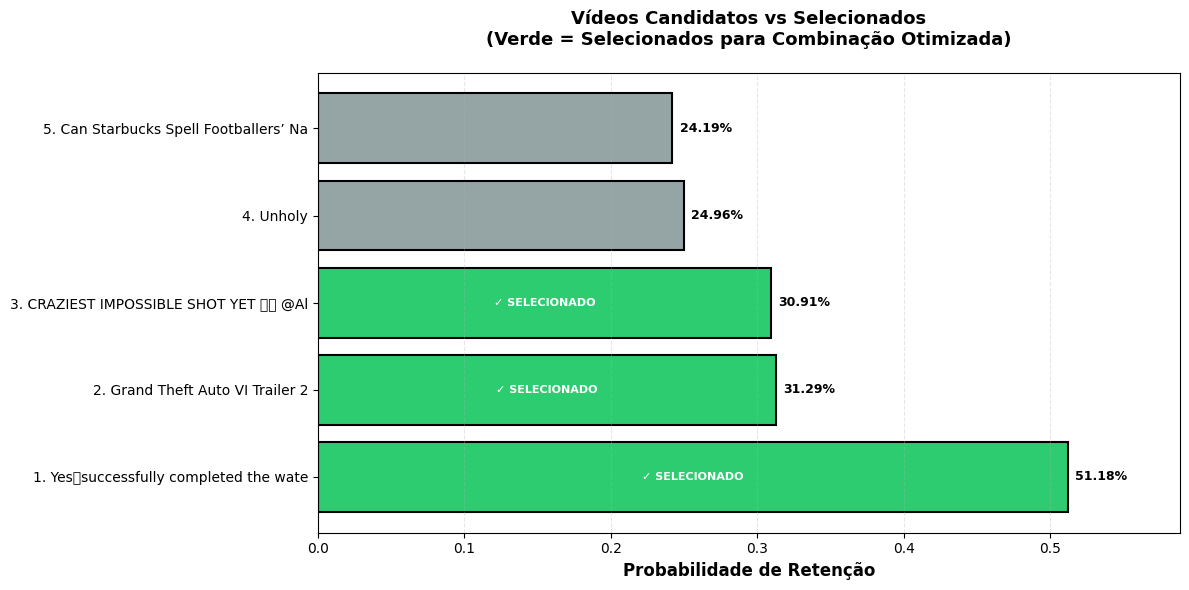

In [ ]:
# Criar DataFrame com comparação
df_comparacao = pd.DataFrame({
    'Video_ID': videos_ids,
    'Título': [titulos_map[v][:40] for v in videos_ids],
    'Probabilidade': [probabilidades[v] for v in videos_ids],
    'Selecionado': [x_3[v].value() == 1 for v in videos_ids]
}).sort_values('Probabilidade', ascending=False).reset_index(drop=True)

print("\nCOMPARAÇÃO DE TODOS OS VÍDEOS CANDIDATOS:")
print(df_comparacao.to_string(index=False))

# Visualização
fig, ax = plt.subplots(figsize=(12, 6))

cores = ['#2ecc71' if sel else '#95a5a6' for sel in df_comparacao['Selecionado']]
barras = ax.barh(range(len(df_comparacao)), df_comparacao['Probabilidade'], color=cores, edgecolor='black', linewidth=1.5)

ax.set_yticks(range(len(df_comparacao)))
ax.set_yticklabels([f"{i+1}. {t[:35]}" for i, t in enumerate(df_comparacao['Título'])])
ax.set_xlabel('Probabilidade de Retenção', fontsize=12, fontweight='bold')
ax.set_title('Vídeos Candidatos vs Selecionados\n(Verde = Selecionados para Combinação Otimizada)', 
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlim(0, max(df_comparacao['Probabilidade']) * 1.15)

# Adicionar valores nas barras
for i, (p, sel) in enumerate(zip(df_comparacao['Probabilidade'], df_comparacao['Selecionado'])):
    ax.text(p + 0.005, i, f'{p:.2%}', va='center', fontsize=9, fontweight='bold')
    if sel:
        ax.text(p/2, i, '✓ SELECIONADO', va='center', ha='center', fontsize=8, color='white', fontweight='bold')

ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


# Resumo Final

## Resultado da Otimização

O modelo prescritivo encontrou a **melhor combinação de 3 vídeos** que:

- **Maximiza** a retenção total
- **Considera** a diversidade de categorias (modelo avançado)
- **Respeita** a restrição de exatamente 3 seleções

